# GRAFICAS

## comparación entre lo estimado  y la comparacion con metricas entre lab quimico y lo estimado

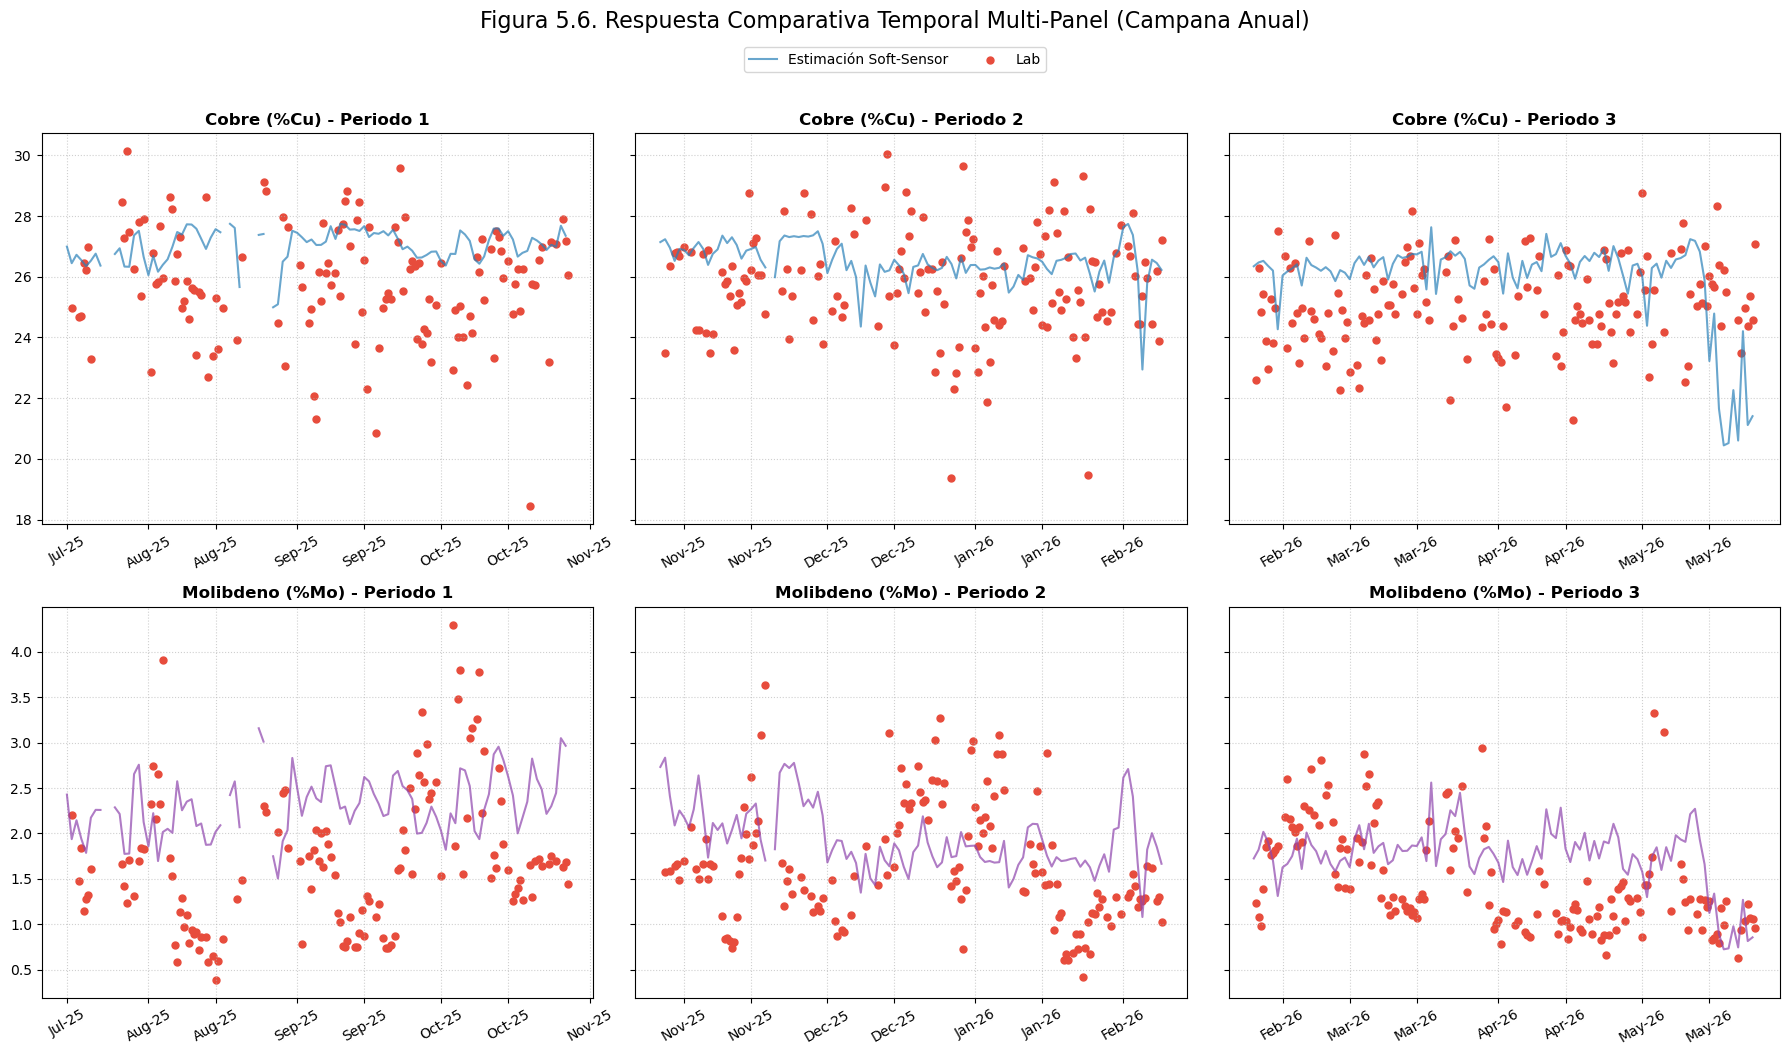

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. Carga de datos
df_pred = pd.read_csv('data/final/soft_sensor_continuous_predictions.csv')
df_pred['timestamp'] = pd.to_datetime(df_pred['timestamp'])
df_audit = pd.read_csv('data/final/soft_sensor_audit_results.csv')
df_audit['timestamp'] = pd.to_datetime(df_audit['timestamp'])

# 2. Definición de periodos (Dividir el tiempo total en tres tercios)
total_start = df_pred['timestamp'].min()
total_end = df_pred['timestamp'].max()
period_length = (total_end - total_start) / 3

periods = [
    (total_start, total_start + period_length),
    (total_start + period_length, total_start + 2 * period_length),
    (total_start + 2 * period_length, total_end)
]

# 3. Configuración de figuras (2 filas: Cobre y Molibdeno | 3 columnas: periodos)
# Usamos 'sharey=row' para que el Cobre y el Molibdeno mantengan su propia escala vertical
elements = [('pCu', 'pCu_Est', 'Cobre (%Cu)', '#2980b9'), 
            ('pMo', 'pMo_Est', 'Molibdeno (%Mo)', '#8e44ad')]

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey='row')

for row, (col_lab, col_est, title, color) in enumerate(elements):
    for col, (start, end) in enumerate(periods):
        ax = axes[row, col]
        
        # Filtrar datos de predicción (resample diario para legibilidad)
        df_pred_sub = df_pred[(df_pred['timestamp'] >= start) & (df_pred['timestamp'] <= end)]
        df_pred_daily = df_pred_sub.set_index('timestamp')[[col_est]].resample('D').mean()
        
        # Filtrar datos de auditoría
        df_lab_sub = df_audit[(df_audit['timestamp'] >= start) & (df_audit['timestamp'] <= end)]
        
        # Graficar
        ax.plot(df_pred_daily.index, df_pred_daily[col_est], color=color, alpha=0.7, linewidth=1.5, label='Estimación Soft-Sensor')
        ax.scatter(df_lab_sub['timestamp'], df_lab_sub[col_lab], color='#e74c3c', s=25, label='Lab')
        
        ax.set_title(f"{title} - Periodo {col + 1}", weight='bold')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%y'))
        plt.setp(ax.get_xticklabels(), rotation=30)
        ax.grid(True, linestyle=':', alpha=0.6)

# Ajustes finales y leyenda
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.02))
plt.suptitle('Figura 5.6. Respuesta Comparativa Temporal Multi-Panel (Campana Anual)', fontsize=16, y=1.05)
plt.tight_layout()
plt.savefig('figura_56_comparativa_anual_detallada.png', dpi=300)
plt.show()

## comparacion directa entre lo estimado y lab quimico

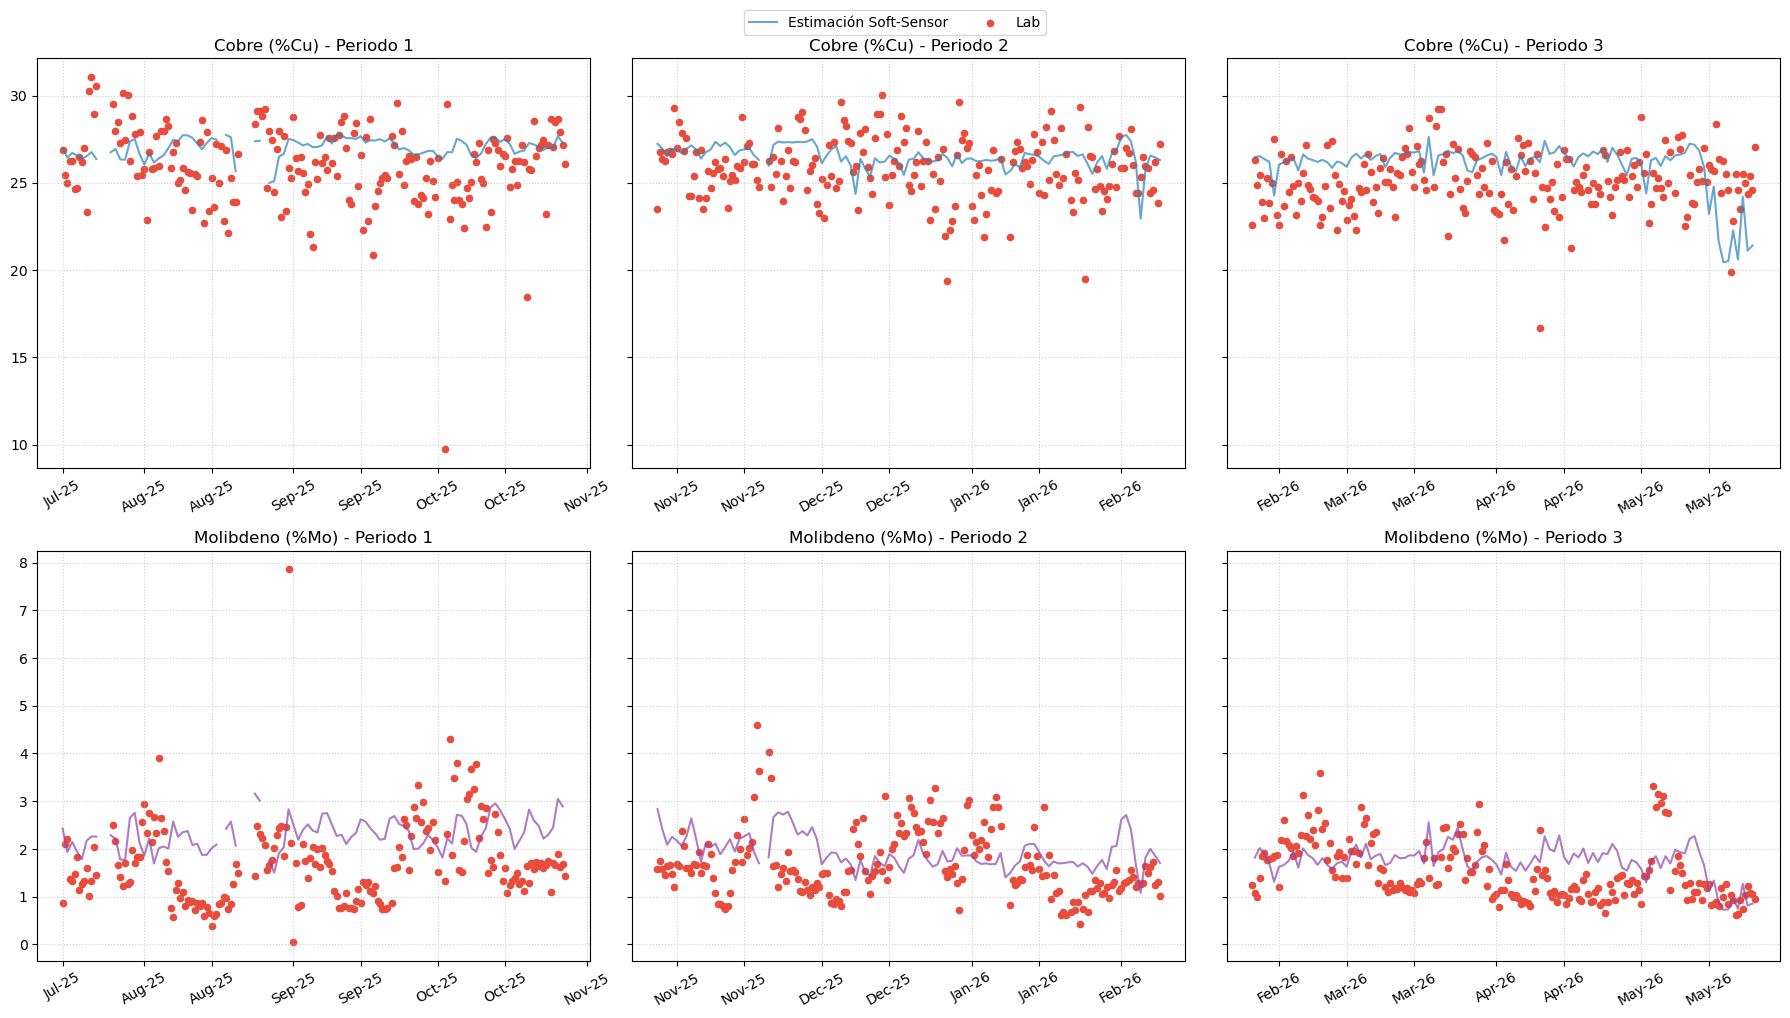

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. Carga de datos
df_pred = pd.read_csv('data/final/soft_sensor_continuous_predictions.csv')
df_pred['timestamp'] = pd.to_datetime(df_pred['timestamp'])
df_lab = pd.read_csv('data/processed/assays_clean_no_duplicates.csv')
df_lab['timestamp'] = pd.to_datetime(df_lab['timestamp'])

# Remuestreo diario para suavizar la línea continua
df_pred_daily = df_pred.set_index('timestamp').resample('D').mean().reset_index()

# 2. Definición de periodos (Dividir el tiempo total en tres tercios)
total_start = df_pred['timestamp'].min()
total_end = df_pred['timestamp'].max()
period_length = (total_end - total_start) / 3

periods = [
    (total_start, total_start + period_length),
    (total_start + period_length, total_start + 2 * period_length),
    (total_start + 2 * period_length, total_end)
]

# 3. Configuración de figuras (2 elementos x 3 periodos = 6 subplots)
elements = [('pCu', 'pCu_Est', 'Cobre (%Cu)', '#2980b9'), 
            ('pMo', 'pMo_Est', 'Molibdeno (%Mo)', '#8e44ad')]

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey='row')

for row, (col_lab, col_est, title, color) in enumerate(elements):
    for col, (start, end) in enumerate(periods):
        ax = axes[row, col]
        
        # Filtrar datos por periodo
        df_pred_sub = df_pred_daily[(df_pred_daily['timestamp'] >= start) & (df_pred_daily['timestamp'] <= end)]
        df_lab_sub = df_lab[(df_lab['timestamp'] >= start) & (df_lab['timestamp'] <= end)]
        
        # Plotear
        ax.plot(df_pred_sub['timestamp'], df_pred_sub[col_est], color=color, alpha=0.7, label='Estimación Soft-Sensor')
        ax.scatter(df_lab_sub['timestamp'], df_lab_sub[col_lab], color='#e74c3c', s=20, label='Lab')
        
        ax.set_title(f"{title} - Periodo {col + 1}")
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%y'))
        plt.setp(ax.get_xticklabels(), rotation=30)
        ax.grid(True, linestyle=':', alpha=0.6)

# Ajustes finales
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.02))
plt.tight_layout()
plt.savefig('figura_comparativa_anual_detallada.png', dpi=300)
plt.show()

   GENERADOR DE GRÁFICOS ANALÍTICOS: IDENTIFICACIÓN DE OFFSET       

[DataOps] Muestras síncronas listas para graficar: 566


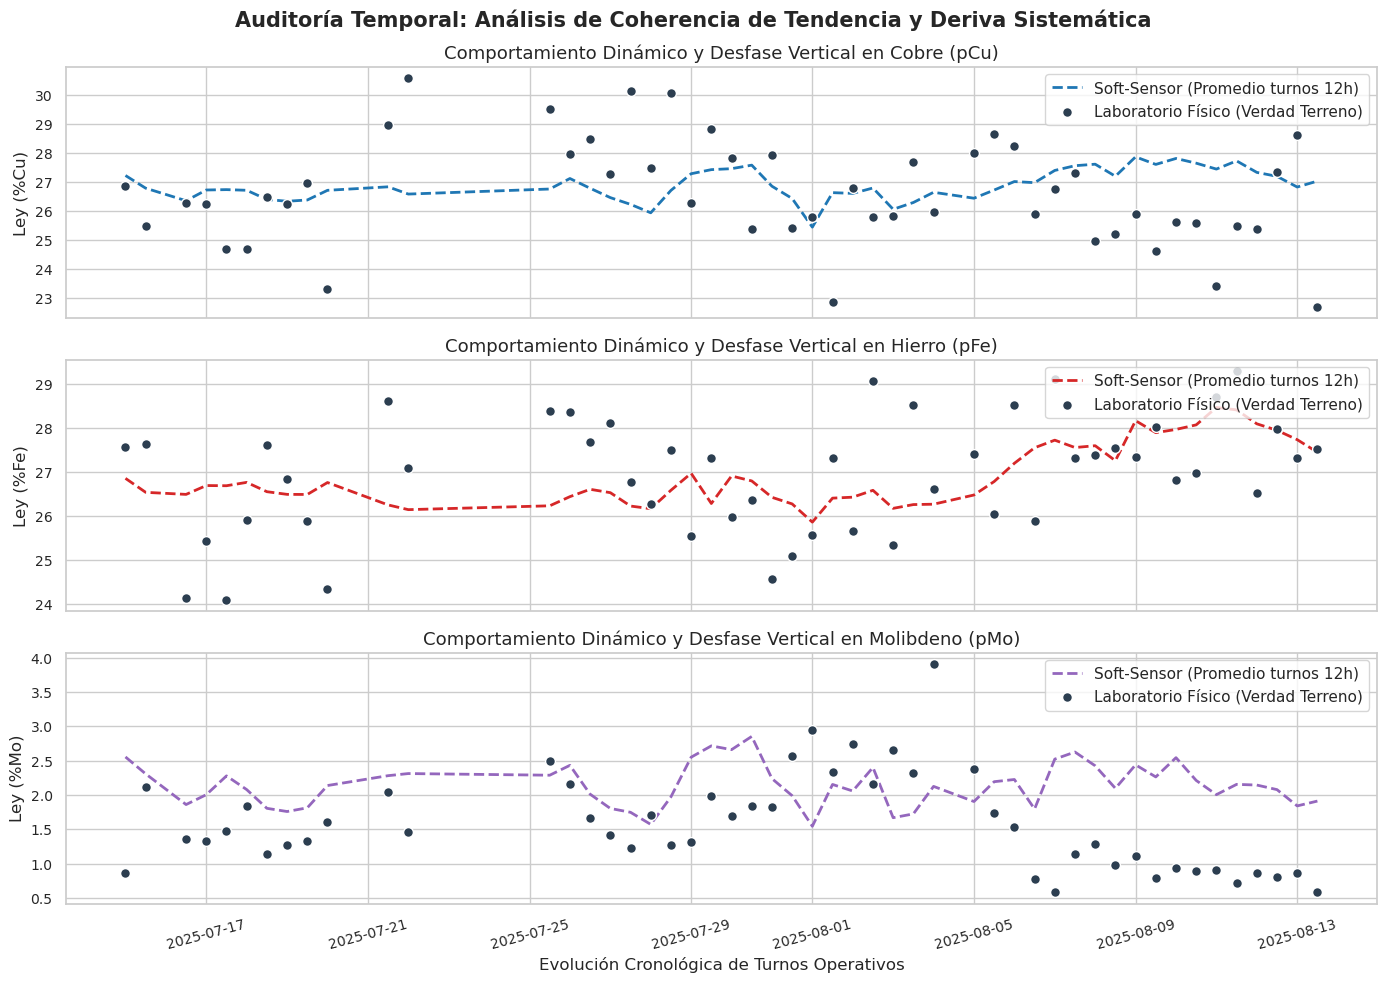

[INFO] Gráfico 1 exportado con éxito: 'grafico_offset_lineal_tiempo.png'


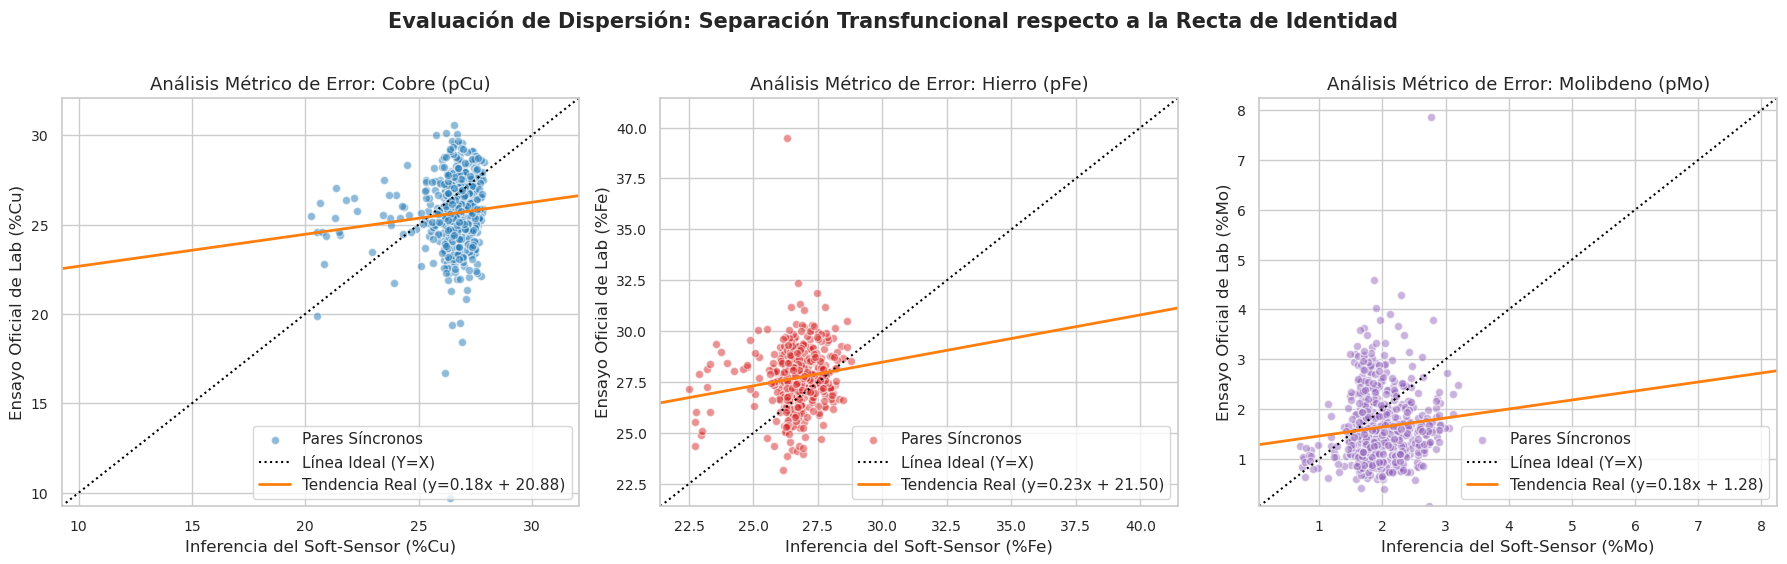

[INFO] Gráfico 2 exportado con éxito: 'grafico_offset_scatter.png'


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilos profesionales para Tesis de Maestría
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 15,
    'font.family': 'sans-serif'
})

print("====================================================================")
print("   GENERADOR DE GRÁFICOS ANALÍTICOS: IDENTIFICACIÓN DE OFFSET       ")
print("====================================================================\n")

# 1. Carga directa de los dos archivos CSV proporcionados
df_predictions_12h = pd.read_csv('data/final/soft_sensor_predictions_12h_averages.csv')
df_predictions_12h['timestamp'] = pd.to_datetime(df_predictions_12h['timestamp'])

df_lab = pd.read_csv('data/processed/assays_clean_no_duplicates.csv')
df_lab['timestamp'] = pd.to_datetime(df_lab['timestamp'])

# 2. Cruce síncrono exacto por marca de tiempo (00:00 y 12:00)
df_audit = pd.merge(df_lab, df_predictions_12h, on='timestamp', how='inner').sort_values('timestamp')
print(f"[DataOps] Muestras síncronas listas para graficar: {len(df_audit)}")

# Mapeo de columnas y configuraciones visuales para el bucle
elements = {
    'Cobre (pCu)': {'real': 'pCu', 'pred': 'pCu_Est_12h', 'unit': '%Cu', 'color': '#1f77b4'},
    'Hierro (pFe)': {'real': 'pFe', 'pred': 'pFe_Est_12h', 'unit': '%Fe', 'color': '#d62728'},
    'Molibdeno (pMo)': {'real': 'pMo', 'pred': 'pMo_Est_12h', 'unit': '%Mo', 'color': '#9467bd'}
}

# ====================================================================
# VISUALIZACIÓN 1: SERIE TEMPORAL COMPARATIVA (Ventana de 50 turnos)
# ====================================================================
# Tomamos un subconjunto cronológico para evitar la saturación de líneas y ver el paralelismo
df_sub_time = df_audit.head(50)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for i, (name, keys) in enumerate(elements.items()):
    # Línea punteada para el Soft-Sensor
    axes[i].plot(df_sub_time['timestamp'], df_sub_time[keys['pred']], 
                 label='Soft-Sensor (Promedio turnos 12h)', color=keys['color'], linewidth=2, linestyle='--')
    # Puntos negros sólidos para el Laboratorio Químico Real
    axes[i].scatter(df_sub_time['timestamp'], df_sub_time[keys['real']], 
                    label='Laboratorio Físico (Verdad Terreno)', color='#2c3e50', edgecolor='w', s=50, zorder=3)
    
    axes[i].set_title(f"Comportamiento Dinámico y Desfase Vertical en {name}")
    axes[i].set_ylabel(f"Ley ({keys['unit']})")
    axes[i].legend(loc='upper right', frameon=True)

axes[2].set_xlabel("Evolución Cronológica de Turnos Operativos")
plt.xticks(rotation=15)
plt.suptitle('Auditoría Temporal: Análisis de Coherencia de Tendencia y Deriva Sistemática', weight='bold')
plt.tight_layout()
plt.savefig('grafico_offset_lineal_tiempo.png', dpi=300)
plt.show()

print("[INFO] Gráfico 1 exportado con éxito: 'grafico_offset_lineal_tiempo.png'")

# ====================================================================
# VISUALIZACIÓN 2: DIAGRAMAS DE DISPERSIÓN (Scatter plots globales)
# ====================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for i, (name, keys) in enumerate(elements.items()):
    x_val = df_audit[keys['pred']]
    y_val = df_audit[keys['real']]
    
    # Nube de puntos elíptica
    axes[i].scatter(x_val, y_val, color=keys['color'], alpha=0.5, edgecolor='w', s=35, label='Pares Síncronos')
    
    # Línea de Identidad Ideal Y = X (donde el modelo sería perfecto con R² = 1.0)
    min_bound = min(x_val.min(), y_val.min()) * 0.95
    max_bound = max(x_val.max(), y_val.max()) * 1.05
    axes[i].plot([min_bound, max_bound], [min_bound, max_bound], color='black', linestyle=':', linewidth=1.5, label='Línea Ideal (Y=X)')
    
    # Ajuste por regresión lineal empírica (Línea de tendencia real observada)
    slope, intercept = np.polyfit(x_val, y_val, 1)
    x_line = np.linspace(min_bound, max_bound, 100)
    axes[i].plot(x_line, slope * x_line + intercept, color='#ff7f0e', linewidth=2, 
                 label=f'Tendencia Real (y={slope:.2f}x + {intercept:.2f})')
    
    axes[i].set_xlim(min_bound, max_bound)
    axes[i].set_ylim(min_bound, max_bound)
    axes[i].set_title(f"Análisis Métrico de Error: {name}")
    axes[i].set_xlabel(f"Inferencia del Soft-Sensor ({keys['unit']})")
    axes[i].set_ylabel(f"Ensayo Oficial de Lab ({keys['unit']})")
    axes[i].legend(loc='lower right', frameon=True)

plt.suptitle('Evaluación de Dispersión: Separación Transfuncional respecto a la Recta de Identidad', weight='bold', y=1.02)
plt.tight_layout()
plt.savefig('grafico_offset_scatter.png', dpi=300)
plt.show()

print("[INFO] Gráfico 2 exportado con éxito: 'grafico_offset_scatter.png'")

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética profesional para formato de Tesis
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'figure.titlesize': 15,
    'font.family': 'sans-serif'
})

print("====================================================================")
print("  AUDITORÍA CONTINUA: SEGMENTACIÓN RÍGIDA EN VENTANAS DE 3 MESES    ")
print("====================================================================\n")

# 1. Ingesta y parseo de series temporales
df_predictions_12h = pd.read_csv('data/final/soft_sensor_predictions_12h_averages.csv')
df_predictions_12h['timestamp'] = pd.to_datetime(df_predictions_12h['timestamp'])

df_lab = pd.read_csv('data/processed/assays_clean_no_duplicates.csv')
df_lab['timestamp'] = pd.to_datetime(df_lab['timestamp'])

# 2. Reconciliación síncrona exacta
df_audit = pd.merge(df_lab, df_predictions_12h, on='timestamp', how='inner').sort_values('timestamp').reset_index(drop=True)

# 3. Definición de Ventanas de 3 meses (Trimestres Reales del dataset)
# Tu data inicia el 2025-07-15 y termina en mayo de 2026.
time_windows = [
    {"name": "Trimestre 1 (Jul 2025 - Oct 2025)", "start": "2025-07-15", "end": "2025-10-15"},
    {"name": "Trimestre 2 (Oct 2025 - Ene 2026)", "start": "2025-10-15", "end": "2026-01-15"},
    {"name": "Trimestre 3 (Ene 2026 - Abr 2026)", "start": "2026-01-15", "end": "2026-04-15"},
    {"name": "Trimestre 4 (Abr 2026 - Jul 2026)", "start": "2026-04-15", "end": "2026-07-15"}
]

elements = {
    'Cobre (pCu)': {'real': 'pCu', 'pred': 'pCu_Est_12h', 'unit': '%Cu', 'color': '#1f77b4'},
    'Hierro (pFe)': {'real': 'pFe', 'pred': 'pFe_Est_12h', 'unit': '%Fe', 'color': '#d62728'},
    'Molibdeno (pMo)': {'real': 'pMo', 'pred': 'pMo_Est_12h', 'unit': '%Mo', 'color': '#9467bd'}
}

# 4. Bucle de renderizado para las 4 ventanas de 3 meses
for idx, window in enumerate(time_windows):
    # Filtrar estrictamente por los rangos de fecha del trimestre
    df_chunk = df_audit[(df_audit['timestamp'] >= window['start']) & (df_audit['timestamp'] < window['end'])]
    
    if len(df_chunk) == 0:
        print(f"[Aviso] La ventana {window['name']} no contiene registros síncronos. Omitiendo gráfico.")
        continue
        
    print(f"[Procesando] {window['name']} | Puntos síncronos detectados: {len(df_chunk)}")
    
    fig, axes = plt.subplots(3, 1, figsize=(14, 9.5), sharex=True)
    
    for i, (name, keys) in enumerate(elements.items()):
        # A. Curva de Inferencia Continua del Soft-Sensor (Línea Discontinua)
        axes[i].plot(df_chunk['timestamp'], df_chunk[keys['pred']], 
                     label='Soft-Sensor (Promedio móvil 12h)', color=keys['color'], linewidth=2, linestyle='--')
        
        # B. NUEVO: Unir los puntos oficiales de laboratorio químico con una línea sólida delgada
        axes[i].plot(df_chunk['timestamp'], df_chunk[keys['real']], 
                     color='#5a6b7c', linewidth=1.2, linestyle='-', zorder=2, alpha=0.8)
        
        # C. Marcadores discretos de la Verdad Terreno del Laboratorio (Puntos con borde blanco)
        axes[i].scatter(df_chunk['timestamp'], df_chunk[keys['real']], 
                        label='Laboratorio Oficial (Verdad Terreno)', color='#2c3e50', edgecolor='w', s=45, zorder=3)
        
        axes[i].set_ylabel(f"Ley ({keys['unit']})")
        axes[i].set_title(f"Perfil de Comparación para {name}")
        axes[i].legend(loc='upper right', frameon=True)
    
    axes[2].set_xlabel("Escala Cronológica Operativa (Marcas de Tiempo)")
    plt.xticks(rotation=15)
    
    plt.suptitle(f'Auditoría Temporal Histórica: {window["name"]}', weight='bold', y=0.98)
    plt.tight_layout()
    
    # Exportar con resolución apta para impresión de tesis (300 DPI)
    filename = f'grafico_auditoria_trimestral_ventana_{idx + 1}.png'
    plt.savefig(filename, dpi=300)
    plt.close()
    print(f"[ÉXITO] Imagen de alta calidad guardada como: '{filename}'")

print("\n[MÓDULO COMPLETADO] Los 4 archivos trimestrales de series de tiempo han sido generados.")

  AUDITORÍA CONTINUA: SEGMENTACIÓN RÍGIDA EN VENTANAS DE 3 MESES    

[Procesando] Trimestre 1 (Jul 2025 - Oct 2025) | Puntos síncronos detectados: 157
[ÉXITO] Imagen de alta calidad guardada como: 'grafico_auditoria_trimestral_ventana_1.png'
[Procesando] Trimestre 2 (Oct 2025 - Ene 2026) | Puntos síncronos detectados: 165
[ÉXITO] Imagen de alta calidad guardada como: 'grafico_auditoria_trimestral_ventana_2.png'
[Procesando] Trimestre 3 (Ene 2026 - Abr 2026) | Puntos síncronos detectados: 168
[ÉXITO] Imagen de alta calidad guardada como: 'grafico_auditoria_trimestral_ventana_3.png'
[Procesando] Trimestre 4 (Abr 2026 - Jul 2026) | Puntos síncronos detectados: 76
[ÉXITO] Imagen de alta calidad guardada como: 'grafico_auditoria_trimestral_ventana_4.png'

[MÓDULO COMPLETADO] Los 4 archivos trimestrales de series de tiempo han sido generados.
